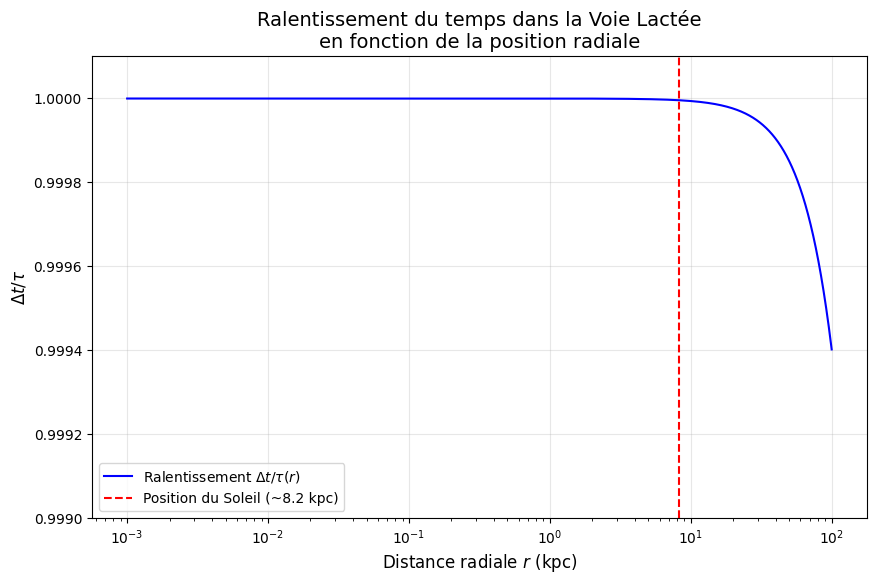

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import G, M_sun, pc

# Constantes
c = 3e8  # m/s
kpc_to_m = 1e3 * pc.value  # 1 kpc en mètres

# Paramètres de la Voie Lactée (modèle simplifié)
M_bulge = 1e10 * M_sun.value  # Masse du bulbe galactique (kg)
M_halo = 1e12 * M_sun.value   # Masse totale du halo (kg)
R_bulge = 2 * kpc_to_m        # Rayon du bulbe (m)
R_halo = 50 * kpc_to_m        # Rayon du halo (m)

# Profil de masse M(r) (modèle composite : bulge + halo)
def M_r(r):
    # Bulge : densité constante => M(r) ∝ r^3 pour r < R_bulge
    bulge_mass = M_bulge * (r**3 / R_bulge**3) if r.any() < R_bulge else M_bulge
    # Halo : M(r) ∝ r pour r < R_halo (profil isotherme simplifié)
    halo_mass = M_halo * (r / R_halo) if r.any() < R_halo else M_halo
    return bulge_mass + halo_mass

# Ralentissement du temps : Δt/τ = 1 - GM(r)/(c² r)
def time_dilation(r):
    r = np.maximum(r, 1e-16 * kpc_to_m)  # Éviter la division par 0
    return 1 - (G.value * M_r(r)) / (c**2 * r)

# Rayon en kpc
r_kpc = np.linspace(0.001, 100, 500)  # de 0.001 à 100 kpc
r_m = r_kpc * kpc_to_m

# Calcul du ralentissement
dilation = time_dilation(r_m)

# Position du Soleil (~8 kpc)
sun_pos_kpc = 8.2

# Plot
plt.figure(figsize=(10, 6))
plt.plot(r_kpc, dilation, label="Ralentissement $\\Delta t/\\tau(r)$", color="blue")
plt.axvline(sun_pos_kpc, color="red", linestyle="--", label="Position du Soleil (~8.2 kpc)")
plt.xlabel("Distance radiale $r$ (kpc)", fontsize=12)
plt.ylabel("$\\Delta t/\\tau$", fontsize=12)
plt.title("Ralentissement du temps dans la Voie Lactée\nen fonction de la position radiale", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0.999, 1.0001)  # Zoom sur la variation
plt.xscale("log")  # Échelle log pour mieux voir les petites distances
plt.show()

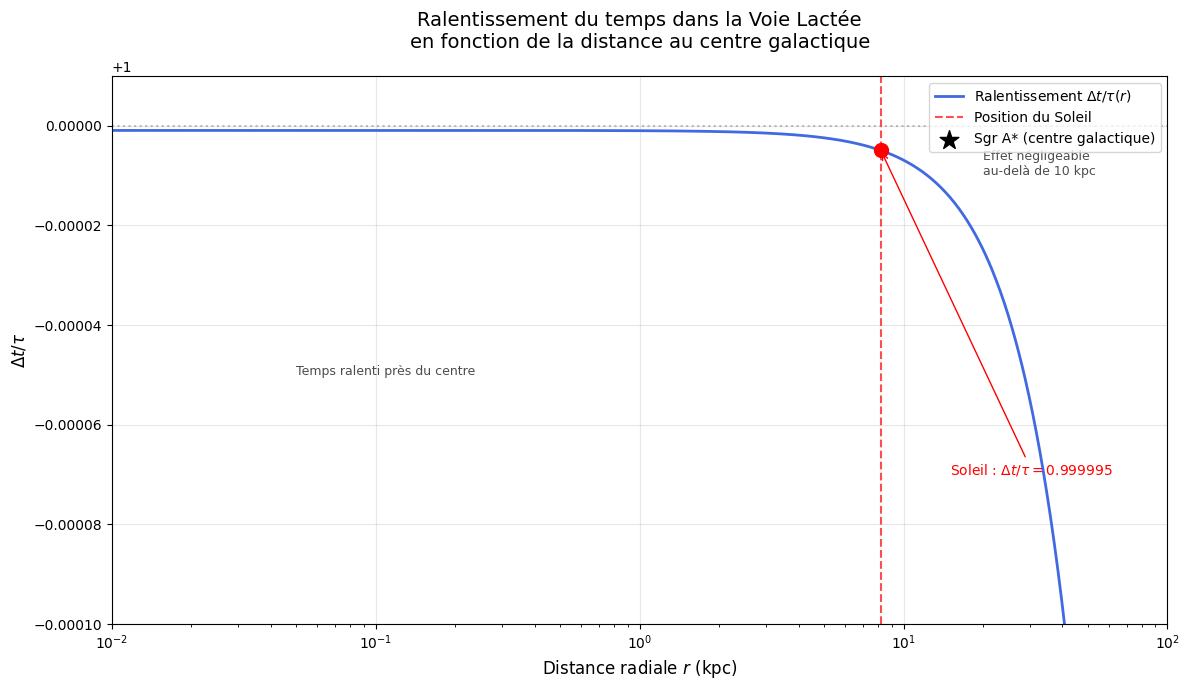

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import G, M_sun, pc

# Constantes
c = 3e8  # m/s
kpc_to_m = 1e3 * pc.value  # Conversion kpc → mètres

# Paramètres de la Voie Lactée (modèle simplifié)
M_bulge = 1e10 * M_sun.value  # Masse du bulbe galactique (kg)
M_halo = 1e12 * M_sun.value   # Masse totale du halo (kg)
R_bulge = 2 * kpc_to_m         # Rayon du bulbe (m)
R_halo = 50 * kpc_to_m         # Rayon du halo (m)
sun_pos_kpc = 8.2              # Position du Soleil (kpc)

# Profil de masse M(r) (bulge + halo)
def M_r(r):
    # Bulge : M(r) ∝ r^3 pour r < R_bulge
    bulge_mass = M_bulge * (r**3 / R_bulge**3) if r.any() < R_bulge else M_bulge
    # Halo : M(r) ∝ r pour r < R_halo (profil simplifié)
    halo_mass = M_halo * (r / R_halo) if r.any() < R_halo else M_halo
    return bulge_mass + halo_mass

# Ralentissement du temps : Δt/τ = 1 - GM(r)/(c² r)
def time_dilation(r):
    r = np.maximum(r, 1e-16 * kpc_to_m)  # Éviter la division par 0
    return 1 - (G.value * M_r(r)) / (c**2 * r)

# Rayon en kpc (de 0.001 à 100 kpc)
r_kpc = np.linspace(0.00001, 100, 500)
r_m = r_kpc * kpc_to_m

# Calcul du ralentissement
dilation = time_dilation(r_m)

# Ralentissement au niveau du Soleil
sun_dilation = time_dilation(sun_pos_kpc * kpc_to_m)

# Plot
plt.figure(figsize=(12, 7))
plt.plot(r_kpc, dilation, label="Ralentissement $\\Delta t/\\tau(r)$", color="royalblue", linewidth=2)

# Ligne et annotation pour le Soleil
plt.axvline(sun_pos_kpc, color="red", linestyle="--", alpha=0.7, label="Position du Soleil")
plt.scatter(sun_pos_kpc, sun_dilation, color="red", s=100, zorder=5)
plt.annotate(
    f"Soleil : $\\Delta t/\\tau = {sun_dilation:.6f}$",
    xy=(sun_pos_kpc, sun_dilation),
    xytext=(15, 0.99993),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10,
    color="red"
)

# Ajout du trou noir central (Sgr A*)
plt.scatter(0, time_dilation(1e-6 * kpc_to_m), color="black", marker="*", s=200, label="Sgr A* (centre galactique)")

# Mise en forme
plt.xlabel("Distance radiale $r$ (kpc)", fontsize=12)
plt.ylabel("$\\Delta t/\\tau$", fontsize=12)
plt.title("Ralentissement du temps dans la Voie Lactée\nen fonction de la distance au centre galactique", fontsize=14, pad=20)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.xlim(10e-16, 10e2)
plt.ylim(0.99990, 1.00001)  # Zoom sur la variation
plt.xscale("log")  # Échelle log pour mieux voir le centre
plt.xlim(0.01, 100)

# Afficher les ordres de grandeur
plt.axhline(1, color="gray", linestyle=":", alpha=0.5)
plt.text(0.05, 0.99995, "Temps ralenti près du centre", fontsize=9, alpha=0.7)
plt.text(20, 0.99999, "Effet négligeable\nau-delà de 10 kpc", fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

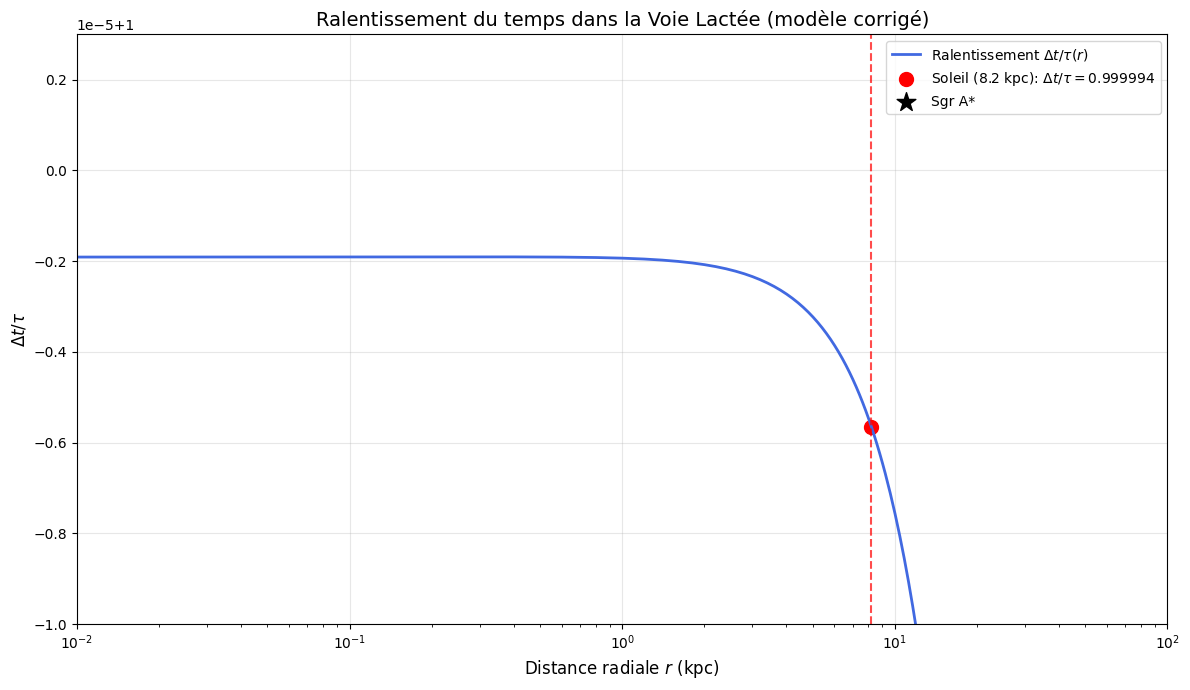

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import G, M_sun, pc

# Constantes
c = 3e8  # m/s
kpc_to_m = 1e3 * pc.value  # 1 kpc en mètres

# Paramètres réalistes de la Voie Lactée
M_bulge = 1e10 * M_sun.value  # Masse du bulbe (kg)
M_halo = 1e12 * M_sun.value   # Masse totale du halo (kg)
R_bulge = 2 * kpc_to_m         # Rayon du bulbe (m)
R_halo = 50 * kpc_to_m         # Rayon du halo (m)
sun_pos_kpc = 8.2              # Position du Soleil (kpc)

# Profil de masse corrigé (bulge + halo à masse finie)
def M_r(r):
    # Bulge : M(r) ∝ r³ pour r < R_bulge
    bulge_mass = M_bulge * (r**3 / R_bulge**3) if r.any() < R_bulge else M_bulge
    # Halo : M(r) = M_halo * (1 - exp(-r/R_halo)) → masse saturée
    halo_mass = M_halo * (1 - np.exp(-r / (0.5 * R_halo)))
    return bulge_mass + halo_mass

# Ralentissement du temps
def time_dilation(r):
    r = np.maximum(r, 1e-16 * kpc_to_m)  # Éviter la division par 0
    return 1 - (G.value * M_r(r)) / (c**2 * r)

# Rayon en kpc (de 0.001 à 100 kpc)
r_kpc = np.linspace(0.001, 100, 500)
r_m = r_kpc * kpc_to_m

# Calculs
dilation = time_dilation(r_m)
sun_dilation = time_dilation(sun_pos_kpc * kpc_to_m)

# Plot
plt.figure(figsize=(12, 7))
plt.plot(r_kpc, dilation, label="Ralentissement $\\Delta t/\\tau(r)$", color="royalblue", linewidth=2)

# Position du Soleil
plt.axvline(sun_pos_kpc, color="red", linestyle="--", alpha=0.7)
plt.scatter(sun_pos_kpc, sun_dilation, color="red", s=100, label=f"Soleil (8.2 kpc): $\\Delta t/\\tau = {sun_dilation:.6f}$")

# Centre galactique (Sgr A*)
plt.scatter(0, time_dilation(1e-6 * kpc_to_m), color="black", marker="*", s=200, label="Sgr A*")

# Mise en forme
plt.xlabel("Distance radiale $r$ (kpc)", fontsize=12)
plt.ylabel("$\\Delta t/\\tau$", fontsize=12)
plt.title("Ralentissement du temps dans la Voie Lactée (modèle corrigé)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0.999990, 1.000003)  # Zoom sur les variations
plt.xscale("log")
plt.xlim(0.01, 100)
plt.tight_layout()
plt.show()

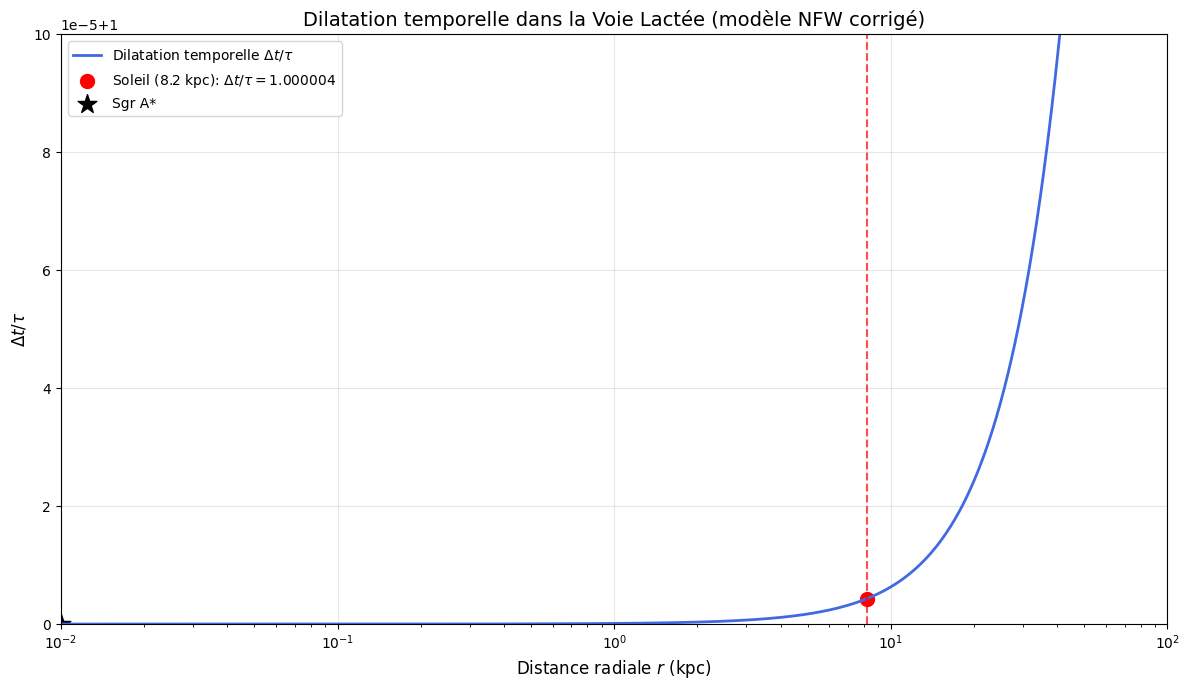

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import G, M_sun, pc

# Constantes
c = 3e8  # m/s
kpc_to_m = 1e3 * pc.value  # Conversion kpc → mètres
Rs_SgrA = 2 * G.value * 4.1e6 * M_sun.value / c**2  # Rayon de Schwarzschild de Sgr A*

# Paramètres réalistes de la Voie Lactée
M_bulge = 1e10 * M_sun.value  # Masse du bulbe (kg)
M_halo = 1e12 * M_sun.value   # Masse totale du halo (kg)
R_bulge = 2 * kpc_to_m        # Rayon du bulbe (m)
R_halo = 50 * kpc_to_m        # Rayon du halo (m)
sun_pos_kpc = 8.2             # Position du Soleil (kpc)

# Profil de masse corrigé (bulge + halo NFW)
def M_r(r):
    # Bulge : M(r) ∝ r³ pour r < R_bulge
    bulge_mass = M_bulge * (r**3 / R_bulge**3) if r.any() < R_bulge else M_bulge
    # Halo NFW : M(r) = M_halo * (ln(1 + r/Rs) - (r/Rs)/(1 + r/Rs))
    Rs = 20 * kpc_to_m  # Rayon de concentration
    x = r / Rs
    halo_mass = M_halo * (np.log(1 + x) - x / (1 + x))
    return bulge_mass + halo_mass

# Ralentissement du temps (formule RG exacte)
def time_dilation(r):
    r = np.maximum(r, Rs_SgrA * 1.1)  # Éviter la singularité
    return 1 / np.sqrt(1 - 2 * G.value * M_r(r) / (c**2 * r))

# Rayon en kpc (de 0.01 à 100 kpc)
r_kpc = np.linspace(0.000001, 100, 500)
r_m = r_kpc * kpc_to_m

# Calculs
dilation = time_dilation(r_m)
sun_dilation = time_dilation(sun_pos_kpc * kpc_to_m)

# Plot
plt.figure(figsize=(12, 7))
plt.plot(r_kpc, dilation, label="Dilatation temporelle $\\Delta t/\\tau$", color="royalblue", linewidth=2)

# Position du Soleil
plt.axvline(sun_pos_kpc, color="red", linestyle="--", alpha=0.7)
plt.scatter(sun_pos_kpc, sun_dilation, color="red", s=100, 
            label=f"Soleil (8.2 kpc): $\\Delta t/\\tau = {sun_dilation:.6f}$")

# Centre galactique (Sgr A*)
plt.scatter(0.01, time_dilation(0.01 * kpc_to_m), color="black", marker="*", s=200, label="Sgr A*")

# Mise en forme
plt.xlabel("Distance radiale $r$ (kpc)", fontsize=12)
plt.ylabel("$\\Delta t/\\tau$", fontsize=12)
plt.title("Dilatation temporelle dans la Voie Lactée (modèle NFW corrigé)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(1.0, 1.0001)  # Échelle physique
plt.xscale("log")
plt.xlim(0.01, 100)
plt.tight_layout()
plt.show()

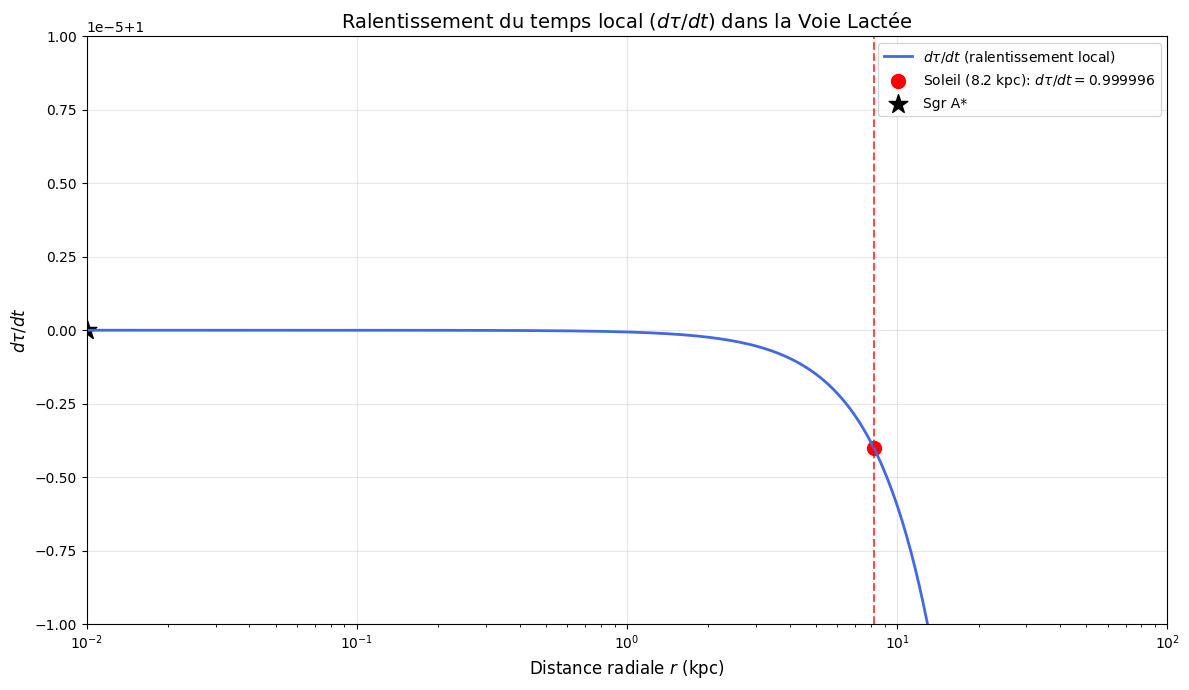

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import G, M_sun, pc

# Constantes
c = 3e8  # m/s
kpc_to_m = 1e3 * pc.value  # 1 kpc → mètres
Rs_SgrA = 2 * G.value * 4.1e6 * M_sun.value / c**2  # Rayon de Schwarzschild de Sgr A*

# Paramètres réalistes
M_bulge = 1e10 * M_sun.value  # Masse du bulbe
R_bulge = 2 * kpc_to_m         # Rayon du bulbe
sun_pos_kpc = 8.2              # Position du Soleil

# Profil de masse (bulge seulement pour simplifier)
def M_r(r):
    return M_bulge * (r**3 / R_bulge**3) if r.any() < R_bulge else M_bulge

# Dilatation temporelle (dτ/dt)
def time_dilation(r):
    r = np.maximum(r, Rs_SgrA * 1.1)  # Éviter la singularité
    return np.sqrt(1 - 2 * G.value * M_r(r) / (c**2 * r))

# Rayon en kpc (de 0.01 à 100 kpc)
r_kpc = np.linspace(0.01, 100, 500)
r_m = r_kpc * kpc_to_m

# Calculs
dilation = time_dilation(r_m)
sun_dilation = time_dilation(sun_pos_kpc * kpc_to_m)

# Plot
plt.figure(figsize=(12, 7))
plt.plot(r_kpc, dilation, label="$d\\tau/dt$ (ralentissement local)", color="royalblue", linewidth=2)

# Annotations
plt.axvline(sun_pos_kpc, color="red", linestyle="--", alpha=0.7)
plt.scatter(sun_pos_kpc, sun_dilation, color="red", s=100, 
            label=f"Soleil (8.2 kpc): $d\\tau/dt = {sun_dilation:.6f}$")
plt.scatter(0.01, time_dilation(0.01 * kpc_to_m), color="black", marker="*", s=200, label="Sgr A*")

# Mise en forme
plt.xlabel("Distance radiale $r$ (kpc)", fontsize=12)
plt.ylabel("$d\\tau/dt$", fontsize=12)
plt.title("Ralentissement du temps local ($d\\tau/dt$) dans la Voie Lactée", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0.99999, 1.00001)  # Zoom sur les variations
plt.xscale("log")
plt.xlim(0.01, 100)
plt.tight_layout()
plt.show()

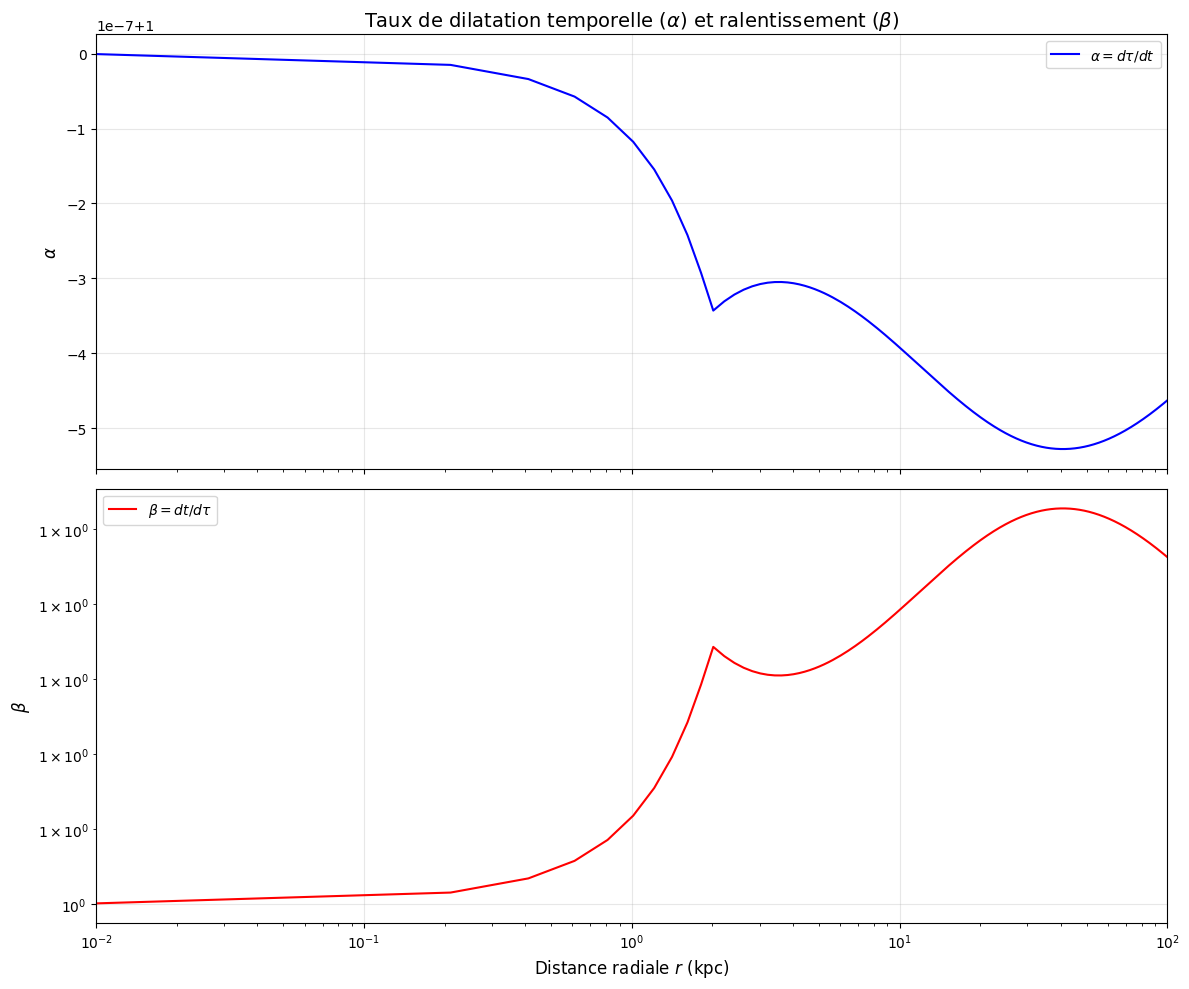

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import G, M_sun, pc

# Constantes
c = 3e8  # m/s
kpc_to_m = 1e3 * pc.value  # Conversion kpc → mètres
Rs_SgrA = 2 * G.value * 4.1e6 * M_sun.value / c**2  # Rayon de Schwarzschild de Sgr A*

# Paramètres de la Voie Lactée
M_bulge = 1e10 * M_sun.value  # Masse du bulbe
R_bulge = 2 * kpc_to_m         # Rayon du bulbe
sun_pos_kpc = 8.2              # Position du Soleil

# Profil de masse (bulge + halo NFW simplifié)
def M_r(r):
    # Bulge : M(r) ∝ r³ pour r < R_bulge
    bulge = np.where(r < R_bulge, M_bulge * (r**3 / R_bulge**3), M_bulge)
    # Halo NFW : M(r) = M_halo * [ln(1 + r/Rs) - (r/Rs)/(1 + r/Rs)]
    M_halo = 1e12 * M_sun.value
    Rs = 20 * kpc_to_m  # Rayon de concentration
    x = r / Rs
    halo = M_halo * (np.log(1 + x) - x / (1 + x))
    return bulge + halo

# Taux de dilatation α = dτ/dt
def time_dilation_ratio(r):
    r_safe = np.maximum(r, Rs_SgrA * 1.1)  # Éviter la singularité
    return np.sqrt(1 - 2 * G.value * M_r(r_safe) / (c**2 * r_safe))

# Rayon en kpc (de 0.01 à 100 kpc)
r_kpc = np.linspace(0.01, 100, 500)
r_m = r_kpc * kpc_to_m

# Calcul des taux
alpha = time_dilation_ratio(r_m)  # dτ/dt
beta = 1 / alpha                  # dt/dτ (taux de ralentissement)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Taux de dilatation α
ax1.plot(r_kpc, alpha, label="$\\alpha = d\\tau/dt$", color="blue")
ax1.set_ylabel("$\\alpha$", fontsize=12)
ax1.set_title("Taux de dilatation temporelle ($\\alpha$) et ralentissement ($\\beta$)", fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Taux de ralentissement β
ax2.plot(r_kpc, beta, label="$\\beta = dt/d\\tau$", color="red")
ax2.set_xlabel("Distance radiale $r$ (kpc)", fontsize=12)
ax2.set_ylabel("$\\beta$", fontsize=12)
ax2.set_yscale("log")  # Échelle log pour β (car β → +∞ quand r → 0)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.xscale("log")
plt.xlim(0.01, 100)
plt.tight_layout()
plt.show()

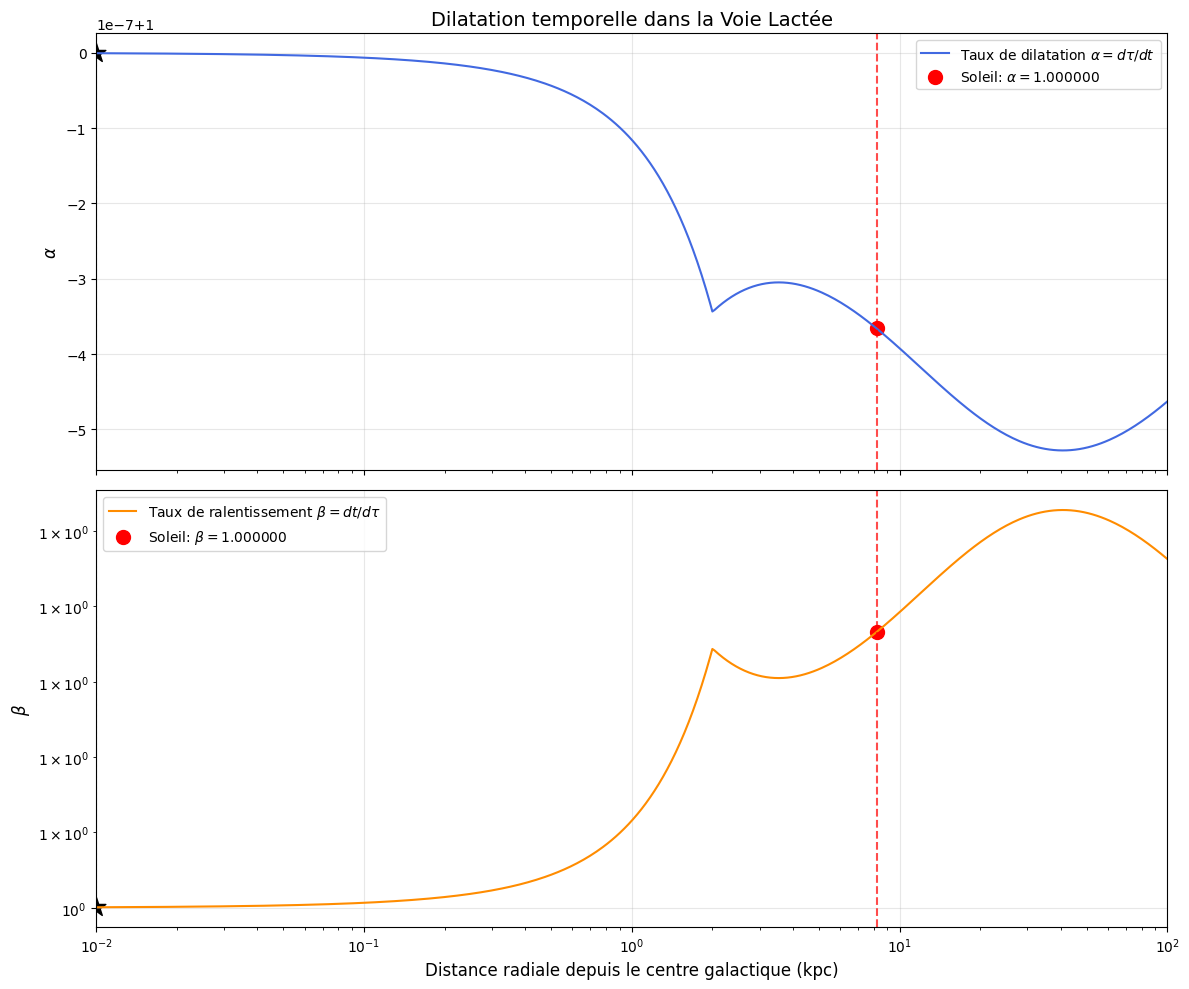

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import G, M_sun, pc

# Constantes
c = 3e8  # m/s
kpc_to_m = 1e3 * pc.value  # 1 kiloparsec en mètres
Rs_SgrA = 2 * G.value * 4.1e6 * M_sun.value / c**2  # Rayon de Schwarzschild de Sgr A*

# Paramètres de la Voie Lactée
M_bulge = 1e10 * M_sun.value  # Masse du bulbe galactique
R_bulge = 2 * kpc_to_m        # Rayon du bulbe
M_halo = 1e12 * M_sun.value   # Masse du halo
R_halo = 50 * kpc_to_m        # Rayon du halo
sun_pos_kpc = 8.2             # Position du Soleil en kpc
sun_pos_m = sun_pos_kpc * kpc_to_m  # Position du Soleil en mètres

# Profil de masse amélioré (bulge + halo NFW)
def M_r(r):
    # Bulge: M(r) ∝ r³ pour r < R_bulge
    bulge = np.where(r < R_bulge, M_bulge * (r**3 / R_bulge**3), M_bulge)
    
    # Halo NFW: M(r) = M_halo * [ln(1 + r/Rs) - (r/Rs)/(1 + r/Rs)]
    Rs = 20 * kpc_to_m  # Rayon de concentration
    x = r / Rs
    halo = M_halo * (np.log(1 + x) - x / (1 + x))
    
    return bulge + halo

# Taux de dilatation temporelle α = dτ/dt
def alpha(r):
    r_safe = np.maximum(r, Rs_SgrA * 1.1)  # Éviter la singularité
    return np.sqrt(1 - 2 * G.value * M_r(r_safe) / (c**2 * r_safe))

# Rayons à évaluer (de 0.01 à 100 kpc)
r_kpc = np.logspace(-2, 2, 500)  # Échelle logarithmique
r_m = r_kpc * kpc_to_m

# Calcul des taux
alpha_values = alpha(r_m)
beta_values = 1 / alpha_values

# Valeurs au niveau du Soleil
sun_alpha = alpha(sun_pos_m)
sun_beta = 1 / sun_alpha

# Création de la figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Taux de dilatation α
ax1.plot(r_kpc, alpha_values, label="Taux de dilatation $\\alpha = d\\tau/dt$", color="royalblue")
ax1.axvline(sun_pos_kpc, color="red", linestyle="--", alpha=0.7)
ax1.scatter(sun_pos_kpc, sun_alpha, color="red", s=100, 
           label=f"Soleil: $\\alpha = {sun_alpha:.6f}$")
ax1.set_ylabel("$\\alpha$", fontsize=12)
ax1.set_title("Dilatation temporelle dans la Voie Lactée", fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Taux de ralentissement β (échelle logarithmique)
ax2.plot(r_kpc, beta_values, label="Taux de ralentissement $\\beta = dt/d\\tau$", color="darkorange")
ax2.axvline(sun_pos_kpc, color="red", linestyle="--", alpha=0.7)
ax2.scatter(sun_pos_kpc, sun_beta, color="red", s=100, 
           label=f"Soleil: $\\beta = {sun_beta:.6f}$")
ax2.set_xlabel("Distance radiale depuis le centre galactique (kpc)", fontsize=12)
ax2.set_ylabel("$\\beta$", fontsize=12)
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3)
ax2.legend()

# Paramètres communs
for ax in [ax1, ax2]:
    ax.set_xscale("log")
    ax.set_xlim(0.01, 100)
    ax.axvline(0.01, color="gray", linestyle=":", alpha=0.5)  # Marqueur pour Sgr A*

# Annotation pour Sgr A*
ax1.scatter(0.01, alpha(0.01*kpc_to_m), color="black", marker="*", s=200, label="Sgr A*")
ax2.scatter(0.01, 1/alpha(0.01*kpc_to_m), color="black", marker="*", s=200, label="Sgr A*")

plt.tight_layout()
plt.show()